In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

In [5]:
# Load processed data
df = pd.read_csv("../data/model_data.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

X = df[["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]]
y = df["target"]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

test_returns = returns["SPY"].loc[y_test.index]

In [6]:
# Re-train best model: Stacking
base_models = [
    ("ridge", Ridge(alpha=1.0)),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )),
    ("extra", ExtraTreesRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
]

stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)
pred_vol = pd.Series(y_pred_stack, index=y_test.index)

In [7]:
# Dynamic VaR using model-predicted volatility
pred_daily_vol = pred_vol / np.sqrt(252)

var_dynamic_5 = norm.ppf(0.05) * pred_daily_vol

violations_dynamic = test_returns < var_dynamic_5

dynamic_violation_rate = violations_dynamic.mean()

print("Expected violation rate: 5%")
print("Dynamic VaR violation rate:", dynamic_violation_rate)
print("Number of Dynamic VaR violations:", violations_dynamic.sum())

Expected violation rate: 5%
Dynamic VaR violation rate: 0.06262626262626263
Number of Dynamic VaR violations: 31


In [8]:
# Benchmark VaR using rolling historical volatility
rolling_daily_vol = test_returns.rolling(21).std()

var_benchmark_5 = norm.ppf(0.05) * rolling_daily_vol

var_benchmark_5 = var_benchmark_5.dropna()

common_index = var_benchmark_5.index.intersection(var_dynamic_5.index)

test_returns_common = test_returns.loc[common_index]
var_dynamic_common = var_dynamic_5.loc[common_index]
var_benchmark_common = var_benchmark_5.loc[common_index]

violations_dynamic_common = test_returns_common < var_dynamic_common
violations_benchmark_common = test_returns_common < var_benchmark_common

dynamic_rate = violations_dynamic_common.mean()
benchmark_rate = violations_benchmark_common.mean()

print("Expected violation rate: 5%")
print("Dynamic VaR violation rate:", dynamic_rate)
print("Benchmark VaR violation rate:", benchmark_rate)

Expected violation rate: 5%
Dynamic VaR violation rate: 0.06526315789473684
Benchmark VaR violation rate: 0.05263157894736842


In [9]:
comparison_var = pd.DataFrame({
    "Method": ["Dynamic VaR", "Rolling Historical VaR"],
    "Violation Rate": [dynamic_rate, benchmark_rate],
    "Number of Violations": [
        violations_dynamic_common.sum(),
        violations_benchmark_common.sum()
    ]
})

comparison_var

,Method,Violation Rate,Number of Violations
0,Dynamic VaR,0.065263,31
1,Rolling Historical VaR,0.052632,25


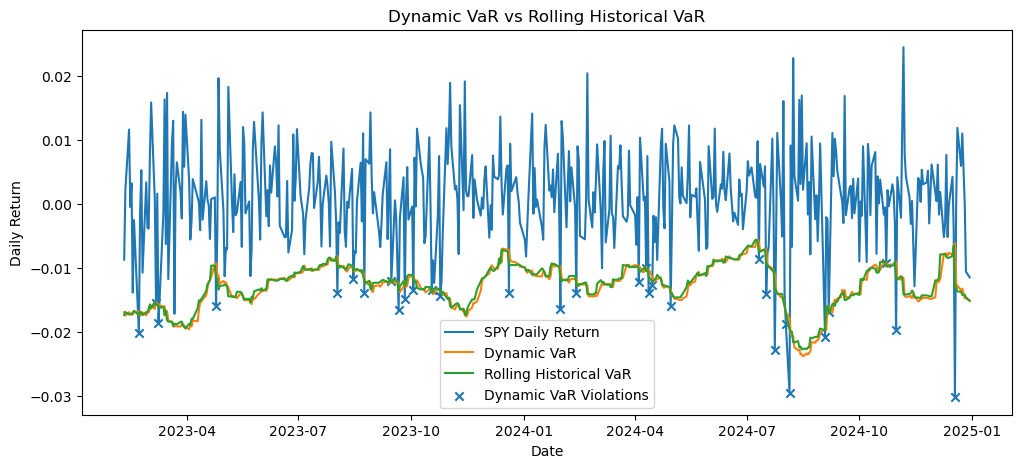

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(test_returns_common.index, test_returns_common, label="SPY Daily Return")
plt.plot(var_dynamic_common.index, var_dynamic_common, label="Dynamic VaR")
plt.plot(var_benchmark_common.index, var_benchmark_common, label="Rolling Historical VaR")

plt.scatter(
    test_returns_common.index[violations_dynamic_common],
    test_returns_common[violations_dynamic_common],
    marker="x",
    label="Dynamic VaR Violations"
)

plt.title("Dynamic VaR vs Rolling Historical VaR")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

### Dynamic VaR Application

To connect volatility forecasting with risk management, this section uses model-predicted volatility to construct a dynamic 5% Value-at-Risk measure for SPY. Instead of assuming that volatility is constant, the dynamic VaR adjusts over time as predicted market risk changes.

A VaR violation occurs when the realized return falls below the predicted VaR threshold. If the model is well calibrated, the violation rate should be close to the theoretical 5% level.

### Benchmark Comparison

The rolling historical VaR serves as a simple benchmark based only on recent realized volatility. Comparing the dynamic VaR with this benchmark allows us to evaluate whether volatility forecasts improve downside risk measurement.

If the dynamic VaR produces a violation rate closer to 5% than the rolling historical VaR, this suggests that model-based volatility forecasts provide a better calibrated measure of market risk.

In [11]:
comparison_var.to_csv("../data/var_comparison.csv")